# MIDV-2019 ID Card Fraud Detection
### Anomaly Detection using MobileNetV2 & ResNet50



## Section 1: Install & Import Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages
!pip install tensorflow opencv-python-headless scikit-learn pillow tqdm matplotlib seaborn -q

In [ ]:
import os
import json
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout,
    Input, Lambda, Flatten
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import pickle



---
##  Section 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print(' Google Drive mounted successfully')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Google Drive mounted successfully



##  Section 3: Configuration & Paths

In [ ]:
# ── CONFIGURE THESE PATHS ─────────────────────────────────────────
# Folder structure on your Google Drive:
#   midv2019/
#     images/
#       DG/   ← TIF images directly here (e.g. 01_alb_id_01.tif)
#       DX/
#       LG/
#       LX/
#     video/  ← MOV / MP4 files
# ─────────────────────────────────────────────────────────────────
DRIVE_ROOT       = '/content/drive/MyDrive/Colab Notebooks/'
MIDV_ROOT        = os.path.join(DRIVE_ROOT, 'midv2019')         # Main dataset folder
IMAGES_ROOT      = os.path.join(MIDV_ROOT, 'images')            # Contains DG, DX, LG, LX
VIDEO_ROOT       = os.path.join(MIDV_ROOT, 'videos')             # Contains MOV/MP4 files
OUTPUT_ROOT      = os.path.join(DRIVE_ROOT, 'midv2019/midv2019_output')  # All saved outputs go here
# ─────────────────────────────────────────────────────────────────

# Sub-output folders
MERGED_IMAGES    = os.path.join(OUTPUT_ROOT, 'merged_images')   # Merged TIF images by doc type
VIDEO_FRAMES     = os.path.join(OUTPUT_ROOT, 'video_frames')    # Extracted video frames
COMBINED_DATA    = os.path.join(OUTPUT_ROOT, 'combined_data')   # Images + frames together
MODELS_DIR       = os.path.join(OUTPUT_ROOT, 'models')          # Saved models
LOGS_DIR         = os.path.join(OUTPUT_ROOT, 'logs')            # Training logs

# Image config
IMG_SIZE         = (224, 224)   # Required by MobileNetV2 and ResNet50
BATCH_SIZE       = 32
EPOCHS           = 30
LEARNING_RATE    = 1e-4
CONDITIONS       = ['DG', 'DX', 'LG', 'LX']

# Fraud detection thresholds
THRESHOLDS = {
    'genuine':    0.85,   # Score >= 0.85   → Genuine ID
    'suspicious': 0.40,   # Score 0.40–0.85 → Suspicious
    'fake':       0.0     # Score < 0.40    → Not an ID / Fake
}

# Create all output directories
for folder in [MERGED_IMAGES, VIDEO_FRAMES, COMBINED_DATA, MODELS_DIR, LOGS_DIR]:
    os.makedirs(folder, exist_ok=True)

# ── Verify paths exist ────────────────────────────────────────────
print(' Configuration set')
print(f'   Dataset root  : {MIDV_ROOT}')
print(f'   Images root   : {IMAGES_ROOT}')
print(f'   Video root    : {VIDEO_ROOT}')
print(f'   Output root   : {OUTPUT_ROOT}')
print(f'   Image size    : {IMG_SIZE}')
print(f'   Batch size    : {BATCH_SIZE}')
print(f'   Epochs        : {EPOCHS}')
print()

# Check each condition folder exists and show file count
for cond in CONDITIONS:
    cond_path = os.path.join(IMAGES_ROOT, cond)
    if os.path.exists(cond_path):
        files = [f for f in os.listdir(cond_path)
                 if f.lower().endswith(('.tif', '.tiff', '.jpg', '.jpeg', '.png'))]
        print(f'    {cond}/ found — {len(files)} image files')
    else:
        print(f'    {cond}/ NOT FOUND at: {cond_path}')

 Configuration set
   Dataset root  : /content/drive/MyDrive/Colab Notebooks/midv2019
   Images root   : /content/drive/MyDrive/Colab Notebooks/midv2019/images
   Video root    : /content/drive/MyDrive/Colab Notebooks/midv2019/videos
   Output root   : /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output
   Image size    : (224, 224)
   Batch size    : 32
   Epochs        : 30

    DG/ found — 90 image files
    DX/ found — 90 image files
    LG/ found — 90 image files
    LX/ found — 90 image files


---
##  Section 4: Merge Images from DG, DX, LG, LX
Copies all TIF images from each condition folder into a unified `merged_images/` folder,
organised by document type (e.g. `01_alb_id`, `02_aut_drvlic_new`, ...).

In [ ]:
def extract_doc_type(filename):

    name = os.path.splitext(filename)[0]   # remove .tif
    parts = name.split('_')
    # Drop the last part if it's a number (frame/clip index)
    if parts and parts[-1].isdigit():
        parts = parts[:-1]
    return '_'.join(parts)


def merge_images(source_root, output_root, conditions):

    total_copied  = 0
    total_skipped = 0
    doc_type_counts = {}

    for condition in conditions:
        condition_path = os.path.join(source_root, condition)

        if not os.path.exists(condition_path):
            print(f'  Condition folder not found: {condition_path}')
            continue

        files = [
            f for f in os.listdir(condition_path)
            if f.lower().endswith(('.tif', '.tiff', '.jpg', '.jpeg', '.png'))
        ]

        print(f' {condition}/ → {len(files)} files found')

        for fname in files:
            # Derive doc type label from filename
            doc_type = extract_doc_type(fname)

            # Create destination subfolder per doc type
            dest_folder = os.path.join(output_root, doc_type)
            os.makedirs(dest_folder, exist_ok=True)

            # Prefix with condition to avoid name collisions across DG/DX/LG/LX
            new_fname = f'{condition}_{fname}'
            src = os.path.join(condition_path, fname)
            dst = os.path.join(dest_folder, new_fname)

            if not os.path.exists(dst):
                shutil.copy2(src, dst)
                total_copied += 1
                doc_type_counts[doc_type] = doc_type_counts.get(doc_type, 0) + 1
            else:
                total_skipped += 1

    print(f'\n Image merge complete!')
    print(f'   Copied          : {total_copied} images')
    print(f'   Skipped         : {total_skipped} (already existed)')
    print(f'   Document types  : {len(doc_type_counts)}')
    return doc_type_counts


doc_counts = merge_images(IMAGES_ROOT, MERGED_IMAGES, CONDITIONS)

# Show counts per document type
print('\n Images per document type:')
for doc, count in sorted(doc_counts.items()):
    print(f'   {doc:30s}: {count} images')

 DG/ → 90 files found
 DX/ → 90 files found
 LG/ → 90 files found
 LX/ → 90 files found

 Image merge complete!
   Copied          : 0 images
   Skipped         : 360 (already existed)
   Document types  : 0

📊 Images per document type:


---
##  Section 5: Extract Frames from Videos
Extracts frames from all `.mov` and `.mp4` video files and saves them
alongside the merged images, organised by document type.

In [ ]:
def extract_video_frames(video_root, output_root, frame_interval=10):
    """
    Extract frames from MOV/MP4 videos.
    frame_interval: extract 1 frame every N frames (default=10 to avoid redundancy)
    """
    total_frames = 0
    total_videos = 0
    failed = []

    video_extensions = ('.mov', '.mp4', '.avi', '.MOV', '.MP4')

    # Walk through all video files recursively
    for root, dirs, files in os.walk(video_root):
        for fname in tqdm(files, desc=f'Processing {os.path.basename(root)}'):
            if not fname.lower().endswith(video_extensions):
                continue

            video_path = os.path.join(root, fname)
            # Try to infer document type from filename or parent folder
            doc_type = os.path.splitext(fname)[0]  # e.g. '01_alb_id'
            # Remove trailing frame/index patterns if any
            doc_type = '_'.join(doc_type.split('_')[:3]) if len(doc_type.split('_')) > 3 else doc_type

            dest_folder = os.path.join(output_root, doc_type)
            os.makedirs(dest_folder, exist_ok=True)

            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                failed.append(fname)
                continue

            frame_idx = 0
            saved = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                if frame_idx % frame_interval == 0:
                    out_name = f'vid_{doc_type}_f{frame_idx:05d}.jpg'
                    out_path = os.path.join(dest_folder, out_name)
                    cv2.imwrite(out_path, frame)
                    saved += 1
                    total_frames += 1
                frame_idx += 1

            cap.release()
            total_videos += 1

    print(f'\n Video frame extraction complete!')
    print(f'   Videos processed : {total_videos}')
    print(f'   Frames extracted : {total_frames}')
    if failed:
        print(f'     Failed videos  : {failed}')

extract_video_frames(VIDEO_ROOT, VIDEO_FRAMES, frame_interval=10)

Processing videos: 100%|██████████| 12/12 [08:34<00:00, 42.84s/it]


 Video frame extraction complete!
   Videos processed : 12
   Frames extracted : 344


---
##  Section 6: Combine Images & Video Frames
Merges the `merged_images/` and `video_frames/` folders into a single `combined_data/` folder.

In [ ]:
def combine_sources(sources, output_root):
    """Combine multiple source directories into one combined dataset folder."""
    total = 0
    for source in sources:
        if not os.path.exists(source):
            print(f'  Source not found: {source}')
            continue
        for doc_type in os.listdir(source):
            src_doc = os.path.join(source, doc_type)
            if not os.path.isdir(src_doc):
                continue
            dst_doc = os.path.join(output_root, doc_type)
            os.makedirs(dst_doc, exist_ok=True)
            for fname in os.listdir(src_doc):
                src_file = os.path.join(src_doc, fname)
                dst_file = os.path.join(dst_doc, fname)
                if not os.path.exists(dst_file):
                    shutil.copy2(src_file, dst_file)
                    total += 1
    print(f' Combined {total} files into: {output_root}')

combine_sources([MERGED_IMAGES, VIDEO_FRAMES], COMBINED_DATA)

# Summary
doc_types = [d for d in os.listdir(COMBINED_DATA) if os.path.isdir(os.path.join(COMBINED_DATA, d))]
print(f'\n Total document types in combined data: {len(doc_types)}')
total_files = sum(len(os.listdir(os.path.join(COMBINED_DATA, d))) for d in doc_types)
print(f' Total files: {total_files}')

 Combined 0 files into: /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/combined_data

 Total document types in combined data: 12
📄 Total files: 704


---
##  Section 7: Preprocessing & Data Loading
Converts all images to JPEG, resizes to 224×224, and prepares train/validation splits.

In [ ]:
def load_and_preprocess(data_dir, img_size=IMG_SIZE):
    """
    Load all images from combined_data folder.
    Returns arrays of images and their doc-type labels.
    """
    images = []
    labels = []
    failed = []

    doc_types = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])

    print(f' Found {len(doc_types)} document types')

    for doc_type in tqdm(doc_types, desc='Loading images'):
        doc_path = os.path.join(data_dir, doc_type)
        for fname in os.listdir(doc_path):
            fpath = os.path.join(doc_path, fname)
            try:
                img = Image.open(fpath).convert('RGB')
                img = img.resize(img_size)
                img_array = np.array(img) / 255.0  # Normalize to [0, 1]
                images.append(img_array)
                labels.append(doc_type)
            except Exception as e:
                failed.append((fname, str(e)))

    print(f'\n Loaded {len(images)} images')
    if failed:
        print(f'  Failed to load {len(failed)} files')

    return np.array(images), np.array(labels)


X, y = load_and_preprocess(COMBINED_DATA)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Save label encoder
with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print(f'\n  Classes: {list(le.classes_)}')
print(f' Dataset shape: {X.shape}')

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'\n Train samples : {len(X_train)}')
print(f'   Val samples   : {len(X_val)}')

 Found 12 document types


Loading images: 100%|██████████| 12/12 [10:14<00:00, 51.23s/it]



 Loaded 704 images

  Classes: [np.str_('DG01'), np.str_('DG02'), np.str_('DG03'), np.str_('DX01'), np.str_('DX02'), np.str_('DX03'), np.str_('LG01'), np.str_('LG02'), np.str_('LG03'), np.str_('LX01'), np.str_('LX02'), np.str_('LX03')]
 Dataset shape: (704, 224, 224, 3)

 Train samples : 563
   Val samples   : 141


---
##  Section 8: Dataset Visualisation
Quick look at sample images and class distribution.

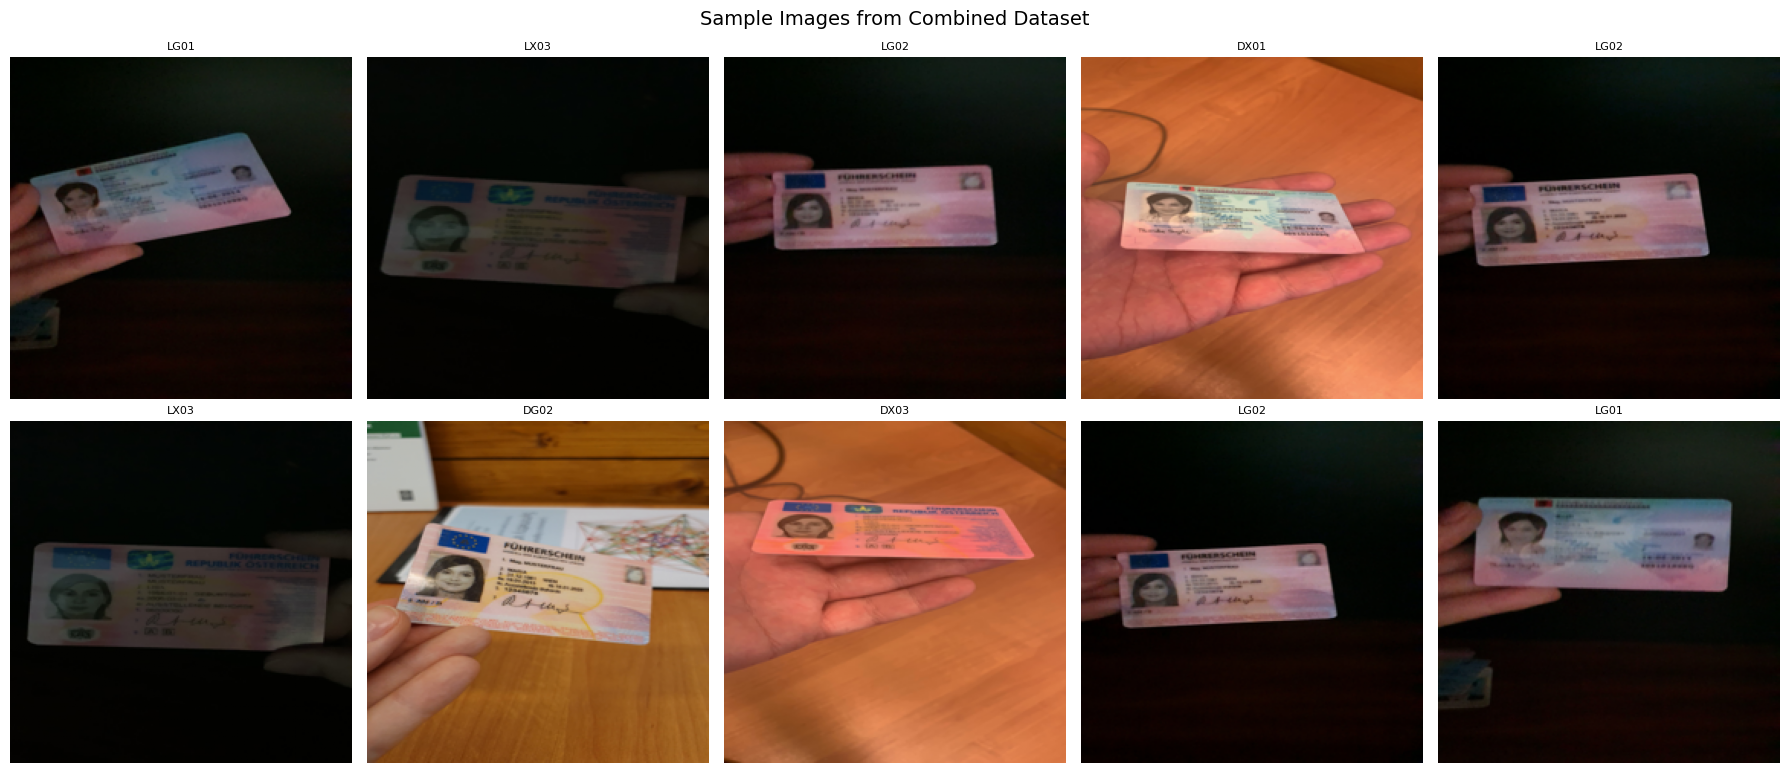

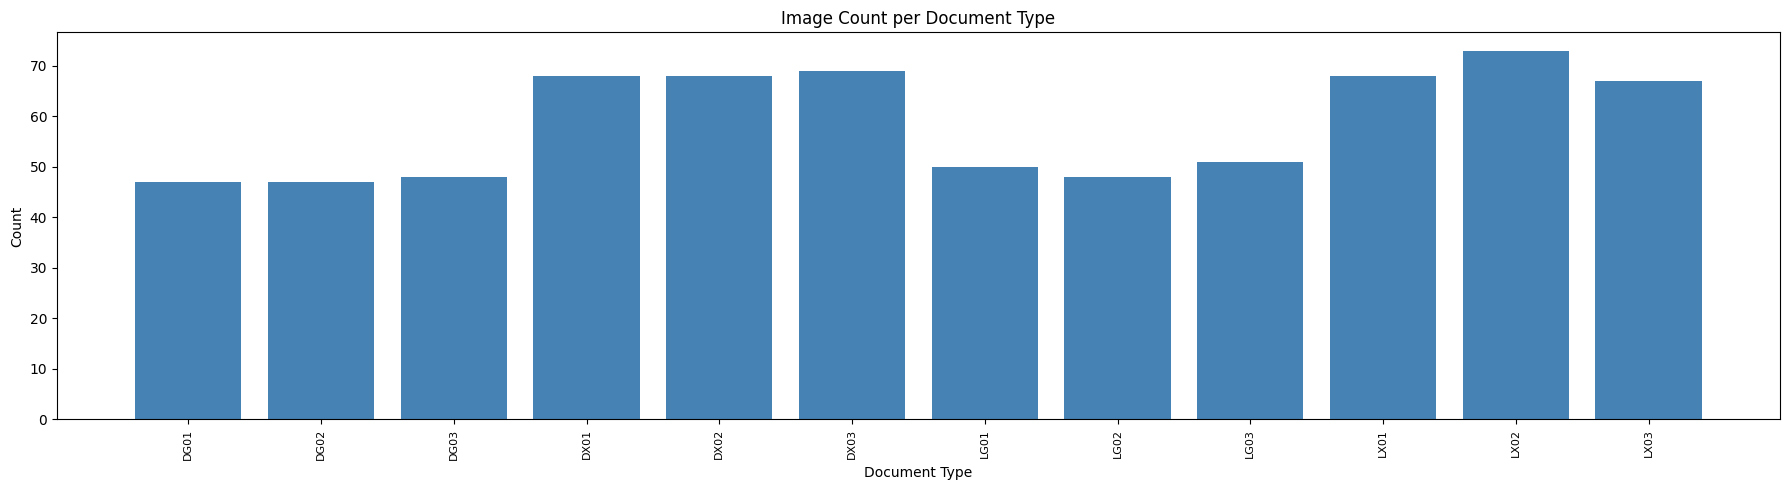

In [ ]:
# Plot sample images
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
indices = np.random.choice(len(X), 10, replace=False)
for i, idx in enumerate(indices):
    axes[i].imshow(X[idx])
    axes[i].set_title(y[idx], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Sample Images from Combined Dataset', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'sample_images.png'))
plt.show()

# Class distribution
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(18, 5))
plt.bar(unique, counts, color='steelblue')
plt.xticks(rotation=90, fontsize=8)
plt.title('Image Count per Document Type')
plt.xlabel('Document Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'class_distribution.png'))
plt.show()

---
##  Section 9: MobileNetV2 Model
Lightweight model — fast inference, suitable for mobile/edge deployment.
Uses transfer learning with ImageNet weights, then fine-tunes on MIDV-2019.

In [ ]:
def build_mobilenet(num_classes, img_size=IMG_SIZE, learning_rate=LEARNING_RATE):
    """Build MobileNetV2-based classifier."""
    base = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze base layers initially
    base.trainable = False

    inputs = Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    # Feature layer — used for anomaly scoring later
    features = Dense(64, activation='relu', name='feature_layer')(x)
    outputs = Dense(num_classes, activation='softmax', name='classifier')(features)

    model = Model(inputs, outputs, name='MobileNetV2_IDFraud')
    model.compile(
        optimizer=Adam(learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


num_classes = len(le.classes_)
mobilenet_model = build_mobilenet(num_classes)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_IDFraud"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,627,852 (10.02 MB)

 Trainable params: 369,868 (1.41 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Data augmentation for training
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,   # ID cards shouldn't be flipped
    brightness_range=[0.8, 1.2]
)

callbacks_mobilenet = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        os.path.join(MODELS_DIR, 'mobilenet_best.h5'),
        save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

print(' Training MobileNetV2...')
mobilenet_history = mobilenet_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks_mobilenet,
    verbose=1
)

print('\n MobileNetV2 training complete!')

 Training MobileNetV2...
Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0763 - loss: 2.6549
Epoch 1: val_loss improved from None to 2.44093, saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/mobilenet_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/mobilenet_best.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.0782 - loss: 2.6156 - val_accuracy: 0.0993 - val_loss: 2.4409 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0867 - loss: 2.5063
Epoch 2: val_loss did not improve from 2.44093
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.0959 - loss: 2.4957 - val_accuracy: 0.0993 - val_loss: 2.4633 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1257 - loss: 2.4740
Epoch 3: val_loss did not improve from 2.44093
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.1119 - loss: 2.4737 - val_accuracy: 0.0993 - val_loss: 2.5150 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1265 - loss: 2.4783
Epoch 4: val_loss did not improve from 2.44093

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.9

In [ ]:
# Fine-tune: Unfreeze top layers of MobileNetV2
print('🔧 Fine-tuning MobileNetV2 (unfreezing top 30 layers)...')
mobilenet_model.layers[1].trainable = True  # Unfreeze base
for layer in mobilenet_model.layers[1].layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(LEARNING_RATE / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_finetune_history = mobilenet_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=callbacks_mobilenet,
    verbose=1
)

# Save final model
mobilenet_model.save(os.path.join(MODELS_DIR, 'mobilenet_final.h5'))
print(' MobileNetV2 fine-tuned and saved!')

🔧 Fine-tuning MobileNetV2 (unfreezing top 30 layers)...
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0564 - loss: 2.5170
Epoch 1: val_loss improved from 2.44093 to 2.43685, saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/mobilenet_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/mobilenet_best.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.0888 - loss: 2.4851 - val_accuracy: 0.0993 - val_loss: 2.4369 - learning_rate: 1.0000e-05
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0888 - loss: 2.4755
Epoch 2: val_loss did not improve from 2.43685
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.0835 - loss: 2.4840 - val_accuracy: 0.0993 - val_loss: 2.4379 - learning_rate: 1.0000e-05
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0819 - loss: 2.4820
Epoch 3: val_loss did not improve from 2.43685
18/18 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.0870 - loss: 2.4709 - val_accuracy: 0.0993 - val_loss: 2.4395 - learning_rate: 1.0000e-05
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1055 - loss: 2.4446
Epoch 4: val_loss did not improve from 2.43685

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.9

 MobileNetV2 fine-tuned and saved!


---
##  Section 10: ResNet50 Model
Deeper model — higher accuracy for complex document patterns.
Better at detecting subtle forgery indicators.

In [ ]:
def build_resnet(num_classes, img_size=IMG_SIZE, learning_rate=LEARNING_RATE):
    """Build ResNet50-based classifier."""
    base = ResNet50(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    features = Dense(64, activation='relu', name='feature_layer')(x)
    outputs = Dense(num_classes, activation='softmax', name='classifier')(features)

    model = Model(inputs, outputs, name='ResNet50_IDFraud')
    model.compile(
        optimizer=Adam(learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


resnet_model = build_resnet(num_classes)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_IDFraud"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,785,356 (94.55 MB)

 Trainable params: 1,197,644 (4.57 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks_resnet = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        os.path.join(MODELS_DIR, 'resnet_best.h5'),
        save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

print(' Training ResNet50...')
resnet_history = resnet_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks_resnet,
    verbose=1
)

print('\n ResNet50 training complete!')

 Training ResNet50...
Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.0780 - loss: 2.5957
Epoch 1: val_loss improved from None to 2.48130, saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 146s 8s/step - accuracy: 0.0764 - loss: 2.5977 - val_accuracy: 0.0993 - val_loss: 2.4813 - learning_rate: 1.0000e-04
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1304 - loss: 2.5022
Epoch 2: val_loss improved from 2.48130 to 2.47786, saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 147s 8s/step - accuracy: 0.1101 - loss: 2.5260 - val_accuracy: 0.0993 - val_loss: 2.4779 - learning_rate: 1.0000e-04
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1304 - loss: 2.4912
Epoch 3: val_loss improved from 2.47786 to 2.47272, saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 147s 8s/step - accuracy: 0.1155 - loss: 2.4803 - val_accuracy: 0.0993 - val_loss: 2.4727 - learning_rate: 1.0000e-04
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.0907 - loss: 2.5175
Epoch 4: val_loss improved from 2.47272 to 2.47120, saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models/resnet_best.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 131s 7s/step - accuracy: 0.0906 - loss: 2.5098 - val_accuracy: 0.0993 - val_loss: 2.4712 - learning_rate: 1.0000e-04
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.0738 - loss: 2.5296
Epoch 5: val_loss did not improve from 2.47120
18/18 ━━━━━━━━━━━━━━━━━━━━ 144s 8s/step - accuracy: 0.0817 - loss: 2.5153 - val_accuracy: 0.1064 - val_loss: 2.4716 - learning_rate: 1.0000e-04
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1116 - loss: 2.5163
Epoch 6: val_loss did not improve from 2.47120
18/18 ━━━━━━━━━━━━━━━━━━━━ 124s 7s/step - accuracy: 0.1012 - loss: 2.5159 - val_accuracy: 0.0993 - val_loss: 2.4750 - learning_rate: 1.0000e-04
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1355 - loss: 2.4634
Epoch 7: val_loss did not improve from 2.47120

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.9

In [ ]:
# Fine-tune ResNet50
print(' Fine-tuning ResNet50 (unfreezing top 20 layers)...')
resnet_model.layers[1].trainable = True
for layer in resnet_model.layers[1].layers[:-5]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(LEARNING_RATE / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_finetune_history = resnet_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=callbacks_resnet,
    verbose=1
)

resnet_model.save(os.path.join(MODELS_DIR, 'resnet_final.h5'))
print(' ResNet50 fine-tuned and saved!')

 Fine-tuning ResNet50 (unfreezing top 20 layers)...
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1235 - loss: 2.4837
Epoch 1: val_loss did not improve from 2.47120
18/18 ━━━━━━━━━━━━━━━━━━━━ 160s 8s/step - accuracy: 0.1083 - loss: 2.4957 - val_accuracy: 0.0993 - val_loss: 2.4713 - learning_rate: 1.0000e-05
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1332 - loss: 2.4678
Epoch 2: val_loss did not improve from 2.47120
18/18 ━━━━━━━━━━━━━━━━━━━━ 128s 7s/step - accuracy: 0.1083 - loss: 2.4888 - val_accuracy: 0.0993 - val_loss: 2.4714 - learning_rate: 1.0000e-05
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1229 - loss: 2.4946
Epoch 3: val_loss did not improve from 2.47120

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
18/18 ━━━━━━━━━━━━━━━━━━━━ 135s 8s/step - accuracy: 0.1083 - loss: 2.4863 - val_accuracy: 0.0993 - val_loss: 2.4713 - learning_rate: 1.0000e-05
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step 

 ResNet50 fine-tuned and saved!


---
##  Section 11: One-Class SVM for Anomaly Detection
Extracts deep features from both models and trains a One-Class SVM.
This is the core of the fraud detection — anything outside the genuine distribution is flagged.

In [ ]:
def extract_features(model, images, batch_size=32):
    """Extract features from the feature_layer of a model."""
    feature_model = Model(
        inputs=model.input,
        outputs=model.get_layer('feature_layer').output
    )
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        feat = feature_model.predict(batch, verbose=0)
        features.append(feat)
    return np.vstack(features)


print(' Extracting features from MobileNetV2...')
mobilenet_features_train = extract_features(mobilenet_model, X_train)
mobilenet_features_val   = extract_features(mobilenet_model, X_val)

print(' Extracting features from ResNet50...')
resnet_features_train = extract_features(resnet_model, X_train)
resnet_features_val   = extract_features(resnet_model, X_val)

# Concatenate features from both models
combined_train = np.concatenate([mobilenet_features_train, resnet_features_train], axis=1)
combined_val   = np.concatenate([mobilenet_features_val,   resnet_features_val],   axis=1)

print(f' Combined feature shape (train): {combined_train.shape}')
print(f' Combined feature shape (val)  : {combined_val.shape}')

 Extracting features from MobileNetV2...
 Extracting features from ResNet50...


 Combined feature shape (train): (563, 128)
 Combined feature shape (val)  : (141, 128)


In [ ]:
# Normalize features
scaler = StandardScaler()
combined_train_scaled = scaler.fit_transform(combined_train)
combined_val_scaled   = scaler.transform(combined_val)

# Save scaler
with open(os.path.join(MODELS_DIR, 'feature_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Train One-Class SVM
print(' Training One-Class SVM...')
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
ocsvm.fit(combined_train_scaled)

# Save OCSVM
with open(os.path.join(MODELS_DIR, 'ocsvm.pkl'), 'wb') as f:
    pickle.dump(ocsvm, f)

print(' One-Class SVM trained and saved!')

# Evaluate on validation set
scores = ocsvm.decision_function(combined_val_scaled)
# Normalize scores to [0, 1]
scores_normalized = (scores - scores.min()) / (scores.max() - scores.min())
print(f'\n Anomaly score stats on validation set:')
print(f'   Min  : {scores_normalized.min():.4f}')
print(f'   Max  : {scores_normalized.max():.4f}')
print(f'   Mean : {scores_normalized.mean():.4f}')

 Training One-Class SVM...
 One-Class SVM trained and saved!

 Anomaly score stats on validation set:
   Min  : 0.0000
   Max  : 1.0000
   Mean : 0.7524


---
##  Section 12: Training Results & Visualisation

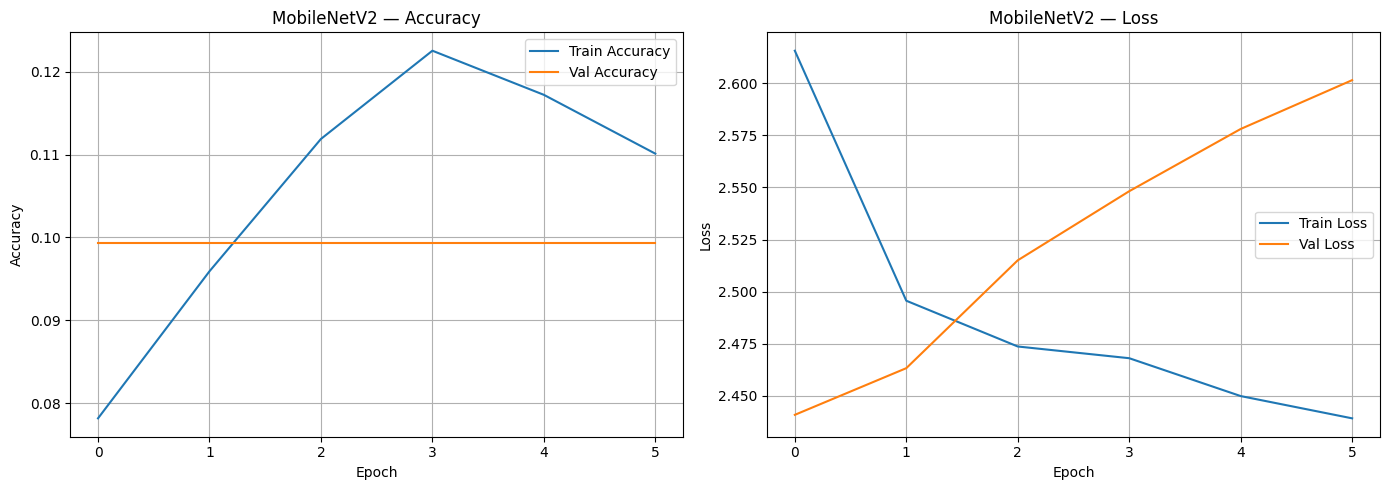

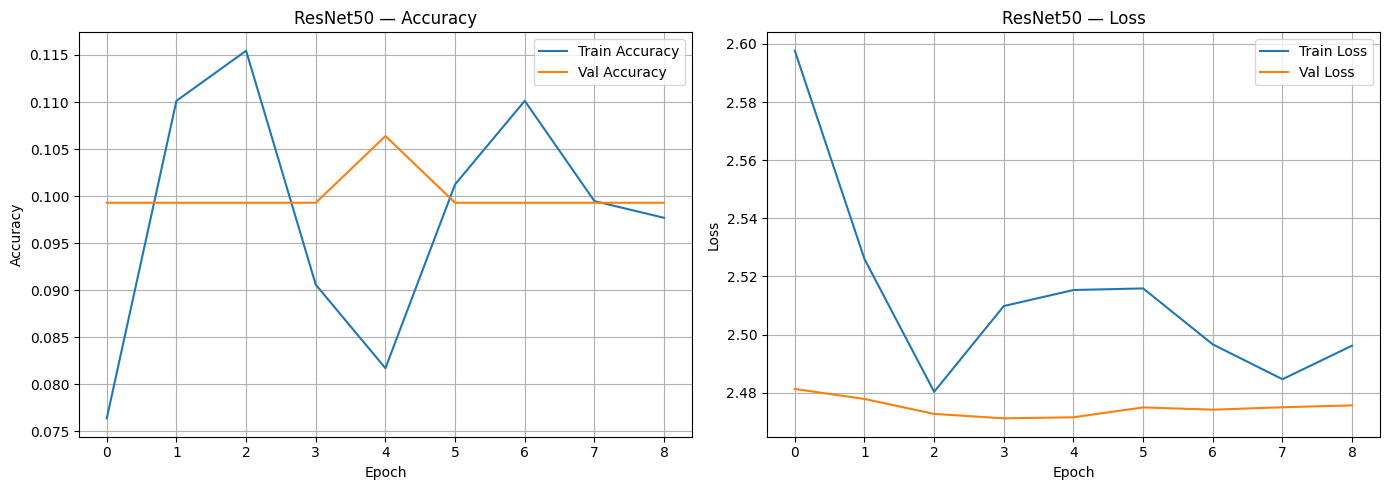

In [ ]:
def plot_training_history(history, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


plot_training_history(
    mobilenet_history,
    'MobileNetV2',
    os.path.join(LOGS_DIR, 'mobilenet_history.png')
)

plot_training_history(
    resnet_history,
    'ResNet50',
    os.path.join(LOGS_DIR, 'resnet_history.png')
)

 MobileNetV2 Validation Results:
   Accuracy : 0.0993
   Loss     : 2.4369

 ResNet50 Validation Results:
   Accuracy : 0.0993
   Loss     : 2.4713
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


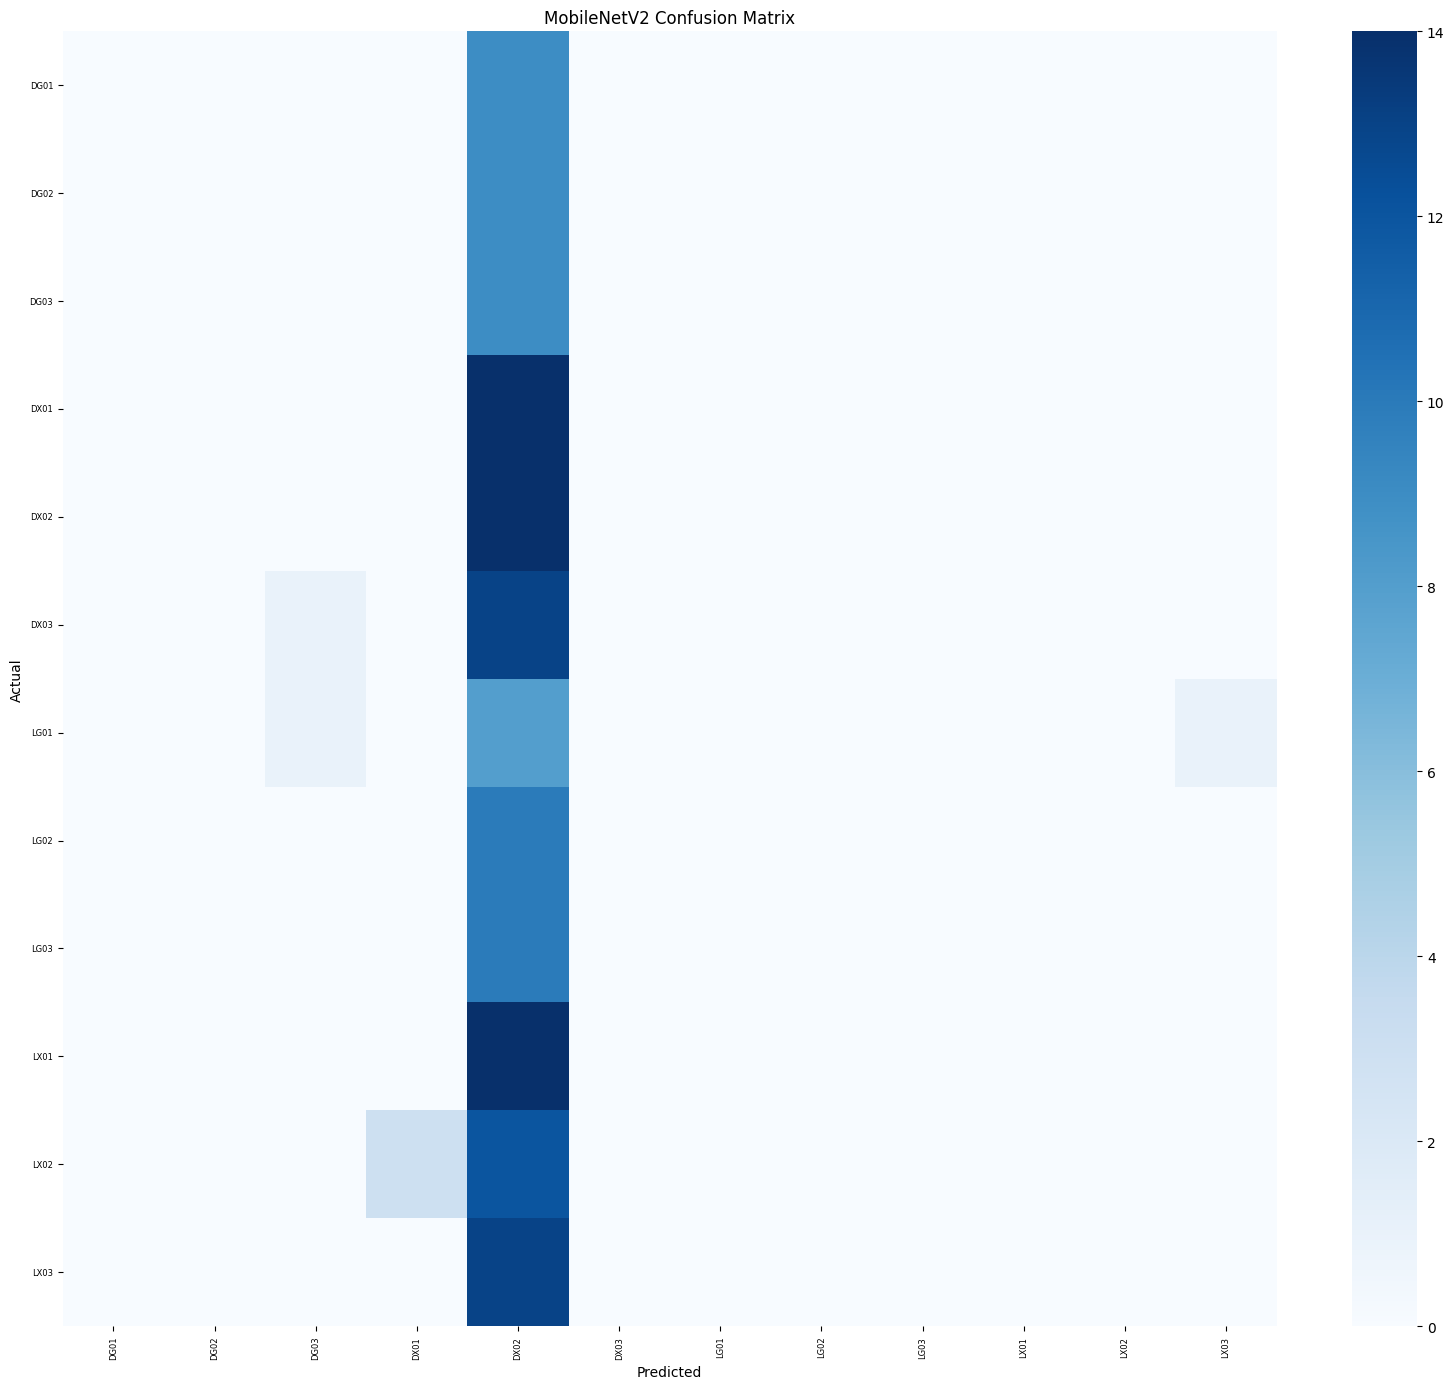

In [ ]:
# Evaluate both models on validation set
print(' MobileNetV2 Validation Results:')
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(X_val, y_val, verbose=0)
print(f'   Accuracy : {mobilenet_acc:.4f}')
print(f'   Loss     : {mobilenet_loss:.4f}')

print('\n ResNet50 Validation Results:')
resnet_loss, resnet_acc = resnet_model.evaluate(X_val, y_val, verbose=0)
print(f'   Accuracy : {resnet_acc:.4f}')
print(f'   Loss     : {resnet_loss:.4f}')

# Confusion matrix for MobileNetV2
y_pred_mobilenet = np.argmax(mobilenet_model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, y_pred_mobilenet)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('MobileNetV2 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'confusion_matrix_mobilenet.png'))
plt.show()

---
##  Section 13: Fraud Detection Scoring Function
This function is what the interface will call. It takes an image or video frame
and returns a score + verdict.

In [ ]:
# Load models and tools (use these functions in your interface)
def load_all_models(models_dir):
    """Load all saved models and tools."""
    mobilenet = load_model(os.path.join(models_dir, 'mobilenet_final.h5'))
    resnet    = load_model(os.path.join(models_dir, 'resnet_final.h5'))

    with open(os.path.join(models_dir, 'ocsvm.pkl'), 'rb') as f:
        ocsvm = pickle.load(f)

    with open(os.path.join(models_dir, 'feature_scaler.pkl'), 'rb') as f:
        scaler = pickle.load(f)

    with open(os.path.join(models_dir, 'label_encoder.pkl'), 'rb') as f:
        le = pickle.load(f)

    return mobilenet, resnet, ocsvm, scaler, le


def preprocess_image(img_input, img_size=IMG_SIZE):
    """
    Accept a file path, numpy array, or PIL Image.
    Returns a normalized numpy array of shape (1, H, W, 3).
    """
    if isinstance(img_input, str):
        img = Image.open(img_input).convert('RGB')
    elif isinstance(img_input, np.ndarray):
        img = Image.fromarray(img_input).convert('RGB')
    else:
        img = img_input.convert('RGB')

    img = img.resize(img_size)
    arr = np.array(img) / 255.0
    return np.expand_dims(arr, axis=0)


def predict_id(img_input, mobilenet, resnet, ocsvm, scaler, le, thresholds=THRESHOLDS):
    """
    Main prediction function.
    Returns a dict with score, verdict, and predicted document type.
    """
    img = preprocess_image(img_input)

    # Extract features
    mn_feat_model = Model(inputs=mobilenet.input,
                          outputs=mobilenet.get_layer('feature_layer').output)
    rn_feat_model = Model(inputs=resnet.input,
                          outputs=resnet.get_layer('feature_layer').output)

    mn_feat = mn_feat_model.predict(img, verbose=0)
    rn_feat = rn_feat_model.predict(img, verbose=0)
    combined = np.concatenate([mn_feat, rn_feat], axis=1)
    combined_scaled = scaler.transform(combined)

    # Anomaly score
    raw_score = ocsvm.decision_function(combined_scaled)[0]

    # Normalize score using training distribution boundaries
    # (In production, save min/max from training for proper normalization)
    score = float(np.clip((raw_score + 1) / 2, 0, 1))

    # Classify document type
    mn_probs = mobilenet.predict(img, verbose=0)[0]
    rn_probs = resnet.predict(img, verbose=0)[0]
    avg_probs = (mn_probs + rn_probs) / 2
    doc_class_idx = np.argmax(avg_probs)
    doc_type = le.inverse_transform([doc_class_idx])[0]
    confidence = float(avg_probs[doc_class_idx])

    # Apply thresholds
    if score >= thresholds['genuine']:
        verdict = 'GENUINE'
        color   = 'green'
    elif score >= thresholds['suspicious']:
        verdict = 'SUSPICIOUS'
        color   = 'orange'
    else:
        verdict = 'FAKE / NOT AN ID'
        color   = 'red'

    return {
        'score':       round(score, 4),
        'verdict':     verdict,
        'color':       color,
        'doc_type':    doc_type,
        'confidence':  round(confidence, 4)
    }


print(' Prediction functions defined and ready')

 Prediction functions defined and ready


---
##  Section 14: Video Prediction Function
Processes a video file frame-by-frame and aggregates scores.

In [ ]:
def predict_video(video_path, mobilenet, resnet, ocsvm, scaler, le,
                  thresholds=THRESHOLDS, frame_interval=15, max_frames=50):
    """
    Run fraud detection on a video file.
    Samples frames at regular intervals and aggregates scores.
    Returns an overall verdict.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {'error': f'Could not open video: {video_path}'}

    frame_results = []
    frame_idx = 0
    processed = 0

    while processed < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = predict_id(frame_rgb, mobilenet, resnet, ocsvm, scaler, le, thresholds)
            frame_results.append(result)
            processed += 1
        frame_idx += 1

    cap.release()

    if not frame_results:
        return {'error': 'No frames could be processed'}

    # Aggregate: use median score for robustness
    all_scores = [r['score'] for r in frame_results]
    median_score = float(np.median(all_scores))

    # Most common doc type
    doc_types = [r['doc_type'] for r in frame_results]
    final_doc_type = max(set(doc_types), key=doc_types.count)

    # Final verdict from median score
    if median_score >= thresholds['genuine']:
        verdict = 'GENUINE'
        color   = 'green'
    elif median_score >= thresholds['suspicious']:
        verdict = 'SUSPICIOUS'
        color   = 'orange'
    else:
        verdict = 'FAKE / NOT AN ID'
        color   = 'red'

    return {
        'score':          round(median_score, 4),
        'verdict':        verdict,
        'color':          color,
        'doc_type':       final_doc_type,
        'frames_checked': processed,
        'all_scores':     all_scores
    }


print(' Video prediction function defined and ready')

 Video prediction function defined and ready


---
##  Section 15: Save All Outputs & Config
Saves threshold config and a model manifest so the interface knows what files to load.

In [ ]:
# Save threshold config
config = {
    'thresholds':   THRESHOLDS,
    'img_size':     list(IMG_SIZE),
    'num_classes':  num_classes,
    'classes':      list(le.classes_),
    'models': {
        'mobilenet':  'mobilenet_final.h5',
        'resnet':     'resnet_final.h5',
        'ocsvm':      'ocsvm.pkl',
        'scaler':     'feature_scaler.pkl',
        'encoder':    'label_encoder.pkl'
    }
}

config_path = os.path.join(MODELS_DIR, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(' All outputs saved!')
print(f'\n Saved files in: {MODELS_DIR}')
for fname in os.listdir(MODELS_DIR):
    fpath = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(fpath)
    print(f'   {fname:40s}  {size/1024:.1f} KB')

 All outputs saved!

 Saved files in: /content/drive/MyDrive/Colab Notebooks/midv2019/midv2019_output/models
   label_encoder.pkl                         0.4 KB
   mobilenet_final.h5                        25486.4 KB
   mobilenet_best.h5                         25486.4 KB
   resnet_best.h5                            106578.7 KB
   resnet_final.h5                           114824.2 KB
   feature_scaler.pkl                        3.4 KB
   ocsvm.pkl                                 54.6 KB
   model_config.json                         0.5 KB


---
##  Section 16: Quick Test
Test the full pipeline on a sample image from the validation set.

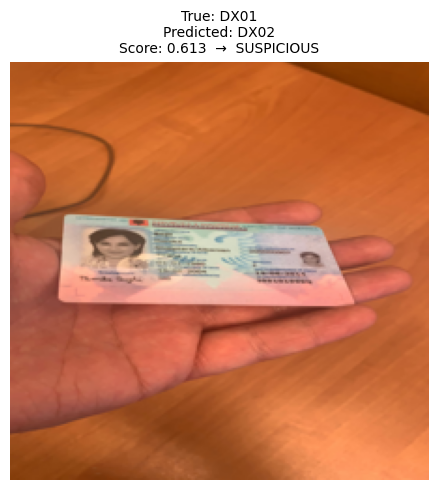


 Full prediction result:
   score          : 0.613
   verdict        : SUSPICIOUS
   color          : orange
   doc_type       : DX02
   confidence     : 0.1422


In [ ]:
# Load all saved models
mn, rn, oc, sc, enc = load_all_models(MODELS_DIR)

# Pick a random validation image
test_idx = np.random.randint(0, len(X_val))
true_label = le.inverse_transform([y_val[test_idx]])[0]

# X_val is float64 [0.0–1.0] — convert to uint8 [0–255] for PIL compatibility
test_img = (X_val[test_idx] * 255).clip(0, 255).astype(np.uint8)

# Run prediction
result = predict_id(test_img, mn, rn, oc, sc, enc)

# Display
plt.figure(figsize=(5, 5))
plt.imshow(test_img)
plt.axis('off')
plt.title(
    f'True: {true_label}\n'
    f'Predicted: {result["doc_type"]}\n'
    f'Score: {result["score"]}  →  {result["verdict"]}',
    fontsize=10
)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'test_prediction.png'))
plt.show()

print('\n Full prediction result:')
for k, v in result.items():
    print(f'   {k:15s}: {v}')